# Flower Prediction Model 

#### 1) Imports

In [ ]:
# General Imports
import os
import json
import random
import time
from collections import defaultdict

# Data handling 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset

from tqdm import tqdm

torch.backends.cudnn.benchmark = True

#### 2) Dataset Paths

In [11]:
DATASET_PATH = "/kaggle/input/datasets/rahmarizk/flower-dataset-reduced/resized_flower_dataset"  

train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")

Count Images Per Class

In [12]:
def count_images_in_class(path):
    class_image_counts = {}

    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)

        if os.path.isdir(class_path):
            image_count = len(os.listdir(class_path))
            class_image_counts[class_name] = image_count

    return class_image_counts

In [13]:
train_counts = count_images_in_class(train_dir)
valid_counts = count_images_in_class(valid_dir)

Dataset Info

In [14]:
train_df = pd.DataFrame(list(train_counts.items()), columns=['Class', 'Train_Count'])
valid_df = pd.DataFrame(list(valid_counts.items()), columns=['Class', 'Valid_Count'])

df = train_df.merge(valid_df, on='Class', how='outer').fillna(0)

In [15]:
print("=== Dataset Summary ===")
print(f"Total classes: {len(df)}")

print("=== Training Set Stats ===")
print(f"Total images: {df['Train_Count'].sum()}")
print(f"Min images/class: {df['Train_Count'].min()}")
print(f"Max images/class: {df['Train_Count'].max()}")
print(f"Average images/class: {df['Train_Count'].mean():.2f}")

print("\n=== Validation Set Stats ===")
print(f"Total images: {df['Valid_Count'].sum()}")
print(f"Min images/class: {df['Valid_Count'].min()}")
print(f"Max images/class: {df['Valid_Count'].max()}")
print(f"Average images/class: {df['Valid_Count'].mean():.2f}")

=== Dataset Summary ===
Total classes: 375
=== Training Set Stats ===
Total images: 33342
Min images/class: 27
Max images/class: 100
Average images/class: 88.91

=== Validation Set Stats ===
Total images: 12192
Min images/class: 1
Max images/class: 100
Average images/class: 32.51


#### 3) Dataset Visualization

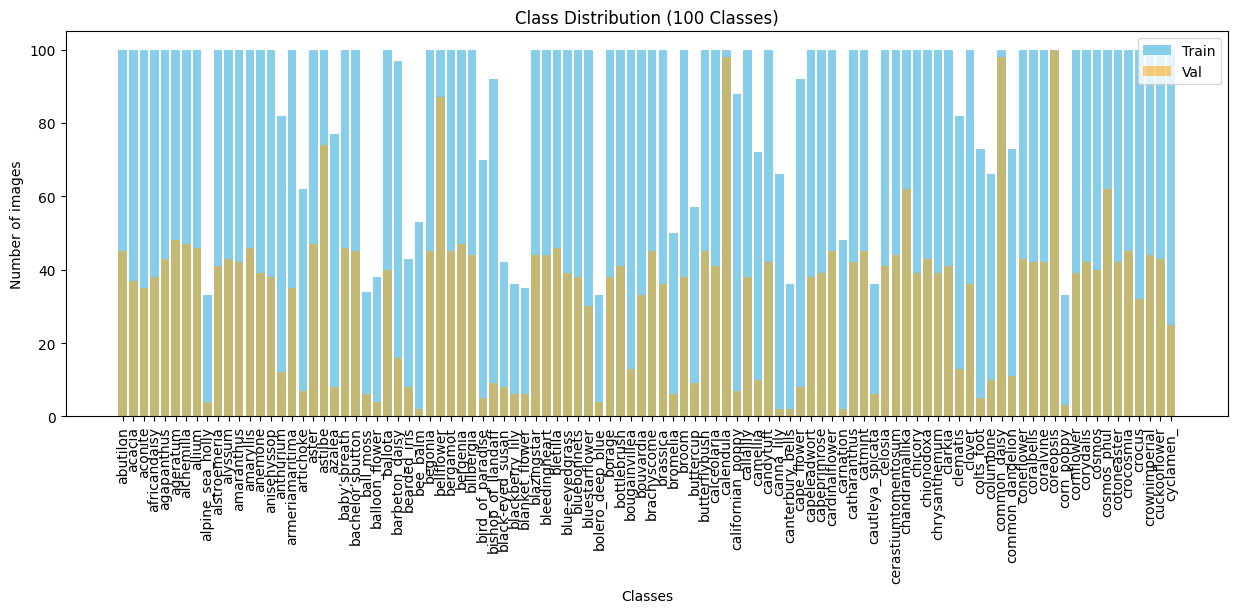

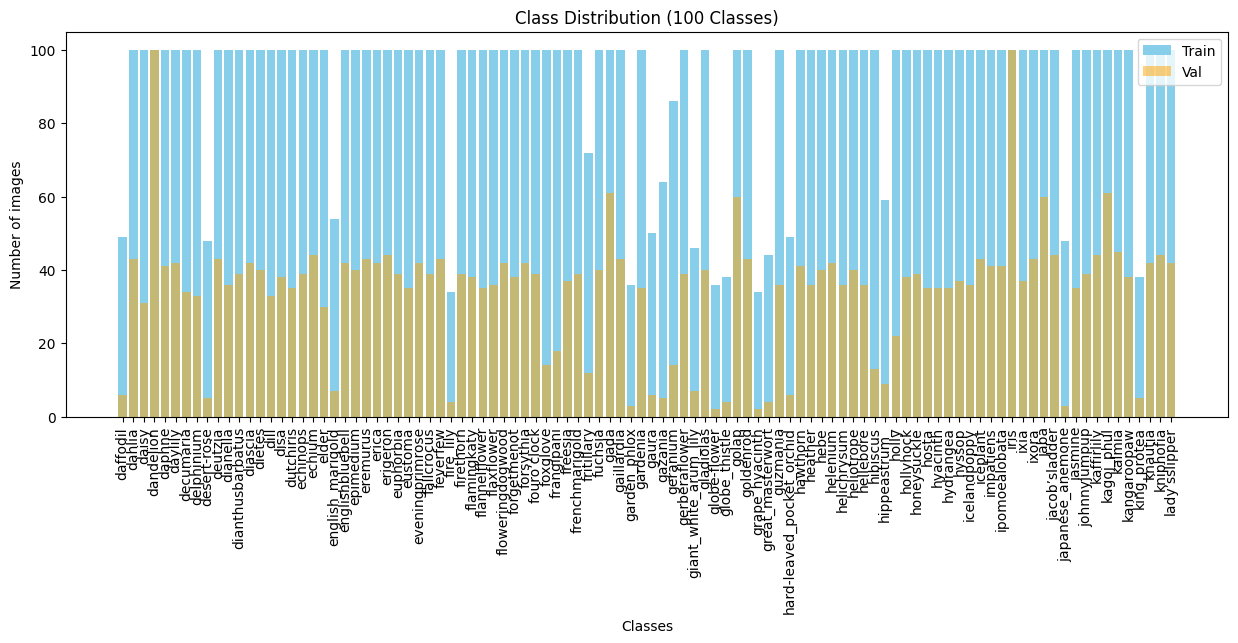

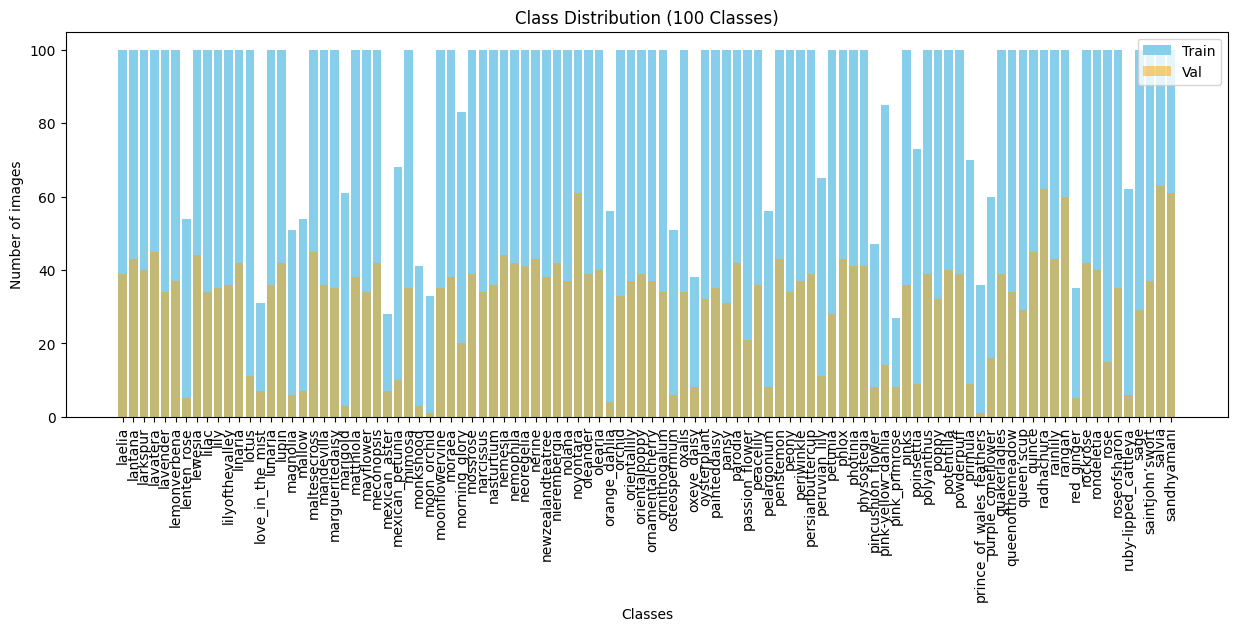

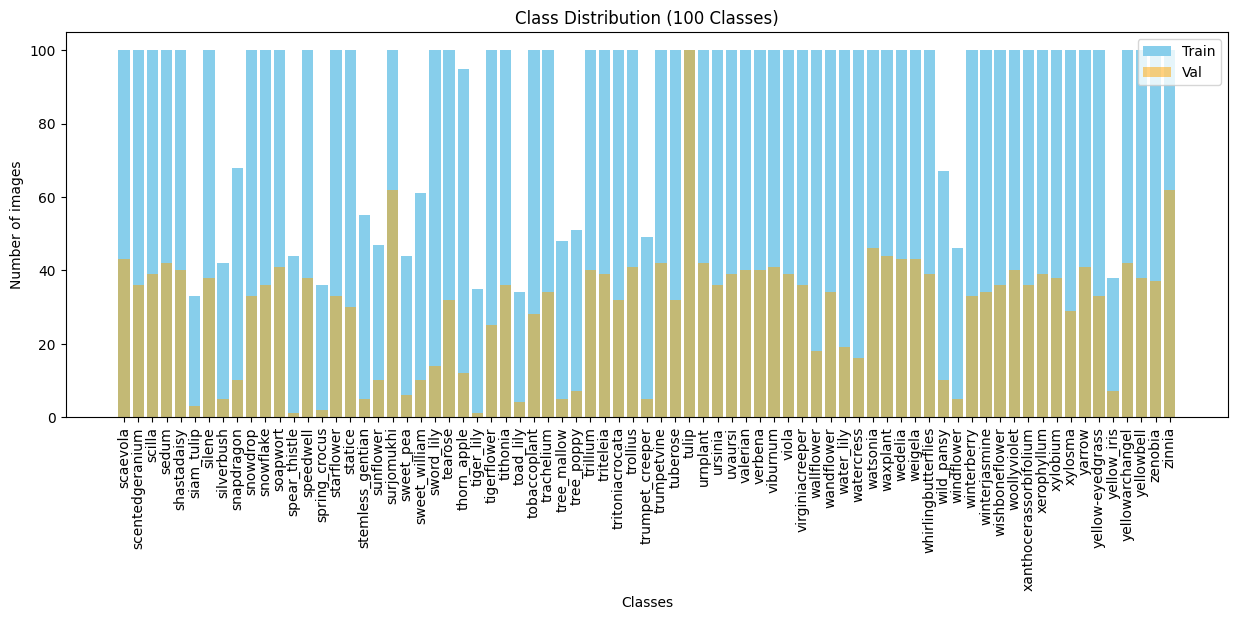

In [16]:
# Visualize class distribution of batches of 100 classes only 
batch_size = 100

for start in range(0, len(df), batch_size):
    subset = df.iloc[start:start + batch_size]

    plt.figure(figsize=(15,5))
    plt.bar(subset["Class"], subset['Train_Count'], label='Train' , color='skyblue')
    plt.bar(subset["Class"], subset['Valid_Count'], alpha=0.5, label='Val' , color='orange')

    plt.xlabel("Classes")
    plt.ylabel("Number of images")
    plt.title("Class Distribution (100 Classes)")
    plt.xticks(rotation=90)  # IMPORTANT so labels don't overlap
    plt.legend()
    plt.show()

In [17]:
df.head()

,Class,Train_Count,Valid_Count
0,abutilon,100,45
1,acacia,100,37
2,aconite,100,35
3,africandaisy,100,38
4,agapanthus,100,43


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#### 4) Data Augmentation

In [19]:
# ImageNet Normalization bec we'll use pretrained model 
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

- Random crop --> Helps model learn different viewpoints
- Random rotation --> improve robustness
- Color variation --> improve generalization

In [20]:
train_transforms = transforms.Compose([
    # transforms.Resize((224,224)),
    transforms.RandomResizedCrop(300, scale=(0.7, 1.0)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), #nweww
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
val_transforms = transforms.Compose([
    # No augmentation for validation
    # Just resizing and normalization
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [22]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(valid_dir, transform=val_transforms)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")

print("Finished initial PyTorch dataset creation with transforms")

Number of training samples: 33342
Number of validation samples: 12192
Finished initial PyTorch dataset creation with transforms


#### 5) DataLoaders

In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=64 , 
    shuffle=False , 
    num_workers=2, 
    persistent_workers=True
)

In [24]:
# Quick check if the weighted sampling is working by looking at a batch of data
images, labels = next(iter(train_loader))
print(f"Batch size: {images.shape}")
print(f"Labels: {labels}")

Batch size: torch.Size([64, 3, 300, 300])
Labels: tensor([ 65, 346, 253, 167, 346, 346, 342, 266,  97, 342, 330, 132, 134, 188,
        313, 164, 358, 344, 153,  22, 259, 235,  13,  59, 363, 171, 236, 170,
        334, 316,  24, 357, 188, 303,  46, 315, 276,  61, 301, 112, 358,  68,
         85,  47, 323, 339, 112, 146, 366, 314, 251, 173, 208, 356, 118, 156,
        132, 341, 309,  61, 297, 173,  95,  65])


#### 6) Model Selection

In [ ]:
# Pretrained Model
# flower_model = models.mobilenet_v2(pretrained=True)
# flower_model = models.efficientnet_b0(pretrained=True)
flower_model = models.efficientnet_b3(pretrained=True)

# False --> feature extraction (freeze base layers)
# True --> fine-tuning (train all layers)

# Freeze ALL backbone
for param in flower_model.features.parameters():
    param.requires_grad = False


# Replace classifier for 375 classes
num_features = flower_model.classifier[1].in_features

flower_model.classifier[1] = nn.Linear(num_features, 375)

flower_model = flower_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 239MB/s]


In [ ]:
class_counts = [0] * len(train_dataset.classes)

for _, label in train_dataset.samples:
    class_counts[label] += 1

# Class weights for imbalanced dataset
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.sum()

Loss function / Optimizer / Scheduler

In [27]:
criterion = nn.CrossEntropyLoss(weight = weights.to(device) , label_smoothing=0.1)
# optimizer = optim.Adam(flower_model.classifier[1].parameters(), lr=1e-2  ) 
optimizer = optim.Adam( flower_model.classifier.parameters(),lr=1e-3)
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, flower_model.parameters()), lr=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

#### 7) Training 

In [28]:
def flower_training (num_epochs, model , train_loader , val_loader , criterion , optimizer, scheduler):

    train_acc_history = []
    val_acc_history = []

    train_loss_history = []
    val_loss_history = []

    for epoch in range(num_epochs):
        # print(f"Epoch: {epoch+1}/{num_epochs}")
        # TRAINING
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        # print("Training batch...")
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1} Training", leave=True)

        for images, labels in train_loader_tqdm:

            images, labels = images.to(device), labels.to(device)
            
            # Zero gradient --> To prevent accumulation from previous batches
            optimizer.zero_grad()

            outputs = model(images)

            # Loss calculation and backpropagation
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Running loss --> Accumulated loss across the epoch --> multiply by batch size to get total loss for the batch 
            running_loss += loss.item() * images.size(0)

            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            train_loader_tqdm.set_postfix(loss=loss.item(), acc=correct/total)

        train_loss = running_loss / total
        train_acc  = correct / total

        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)


        # --- VALIDATION ---
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        # print("Validation batch...")
        val_loader_tqdm = tqdm(val_loader, desc="Validation", leave=True)
        with torch.no_grad():
            for images, labels in val_loader_tqdm:

                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

                val_loader_tqdm.set_postfix(loss=loss.item(), acc=correct/total)   

        val_loss = val_loss / total
        val_acc  = correct / total

        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Step the scheduler
        # scheduler.step()
        # For stage 3 only 
        scheduler.step(val_acc)
    
    return (train_loss_history, train_acc_history, val_loss_history, val_acc_history)

In [57]:
history = flower_training(num_epochs=10, model=flower_model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler)

# Saving the trained model
torch.save(flower_model.state_dict(), "/kaggle/working/flower_model.pth")

Validation: 100%|██████████| 191/191 [00:37<00:00,  5.06it/s, acc=0.384, loss=3.2] 


Epoch [1/10] | Train Loss: 4.4160, Train Acc: 0.3032 | Val Loss: 3.9967, Val Acc: 0.3838


Validation: 100%|██████████| 191/191 [00:37<00:00,  5.13it/s, acc=0.443, loss=2.63]


Epoch [2/10] | Train Loss: 3.1328, Train Acc: 0.5073 | Val Loss: 3.7099, Val Acc: 0.4432


Validation: 100%|██████████| 191/191 [00:36<00:00,  5.22it/s, acc=0.503, loss=2.07]


...

Epoch [8/10] | Train Loss: 2.4371, Train Acc: 0.6521 | Val Loss: 3.4183, Val Acc: 0.5106


Validation: 100%|██████████| 191/191 [00:37<00:00,  5.15it/s, acc=0.517, loss=1.97]


Epoch [9/10] | Train Loss: 2.4252, Train Acc: 0.6563 | Val Loss: 3.2009, Val Acc: 0.5175


Validation: 100%|██████████| 191/191 [00:36<00:00,  5.22it/s, acc=0.514, loss=2.09]


Epoch [10/10] | Train Loss: 2.4222, Train Acc: 0.6576 | Val Loss: 3.5694, Val Acc: 0.5138


In [52]:
with open("/kaggle/working/class_mapping.json", "w") as f:
    json.dump(train_dataset.class_to_idx, f)

In [29]:
def plot_acc(history):
    train_loss_history, train_acc_history, val_loss_history, val_acc_history = history
    
    # Plot training and validation Accuracy
    
    plt.figure(figsize=(12, 4))
    plt.plot(train_acc_history, label='Training Accuracy')
    plt.plot(val_acc_history, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.show()

In [30]:
def plot_loss(history):
    train_loss_history, train_acc_history, val_loss_history, val_acc_history = history

    # Plot training and validation Loss
    plt.figure(figsize=(12, 4))
    plt.plot(train_loss_history, label='Training Loss')
    plt.plot(val_loss_history, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

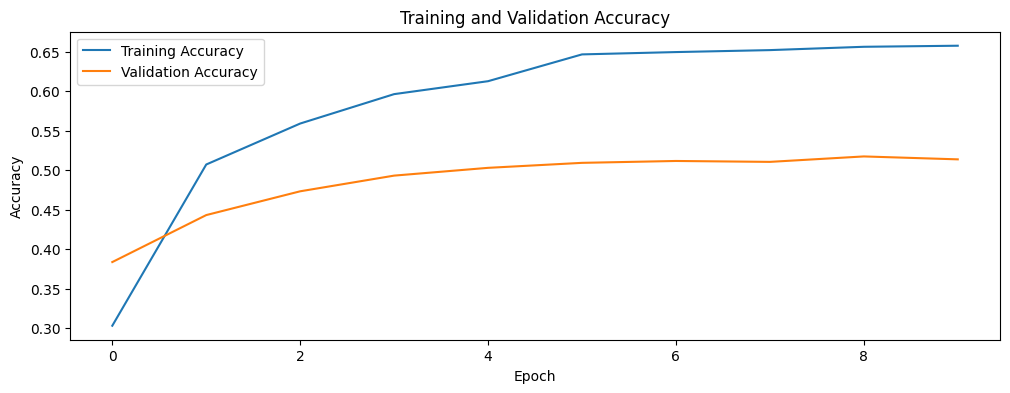

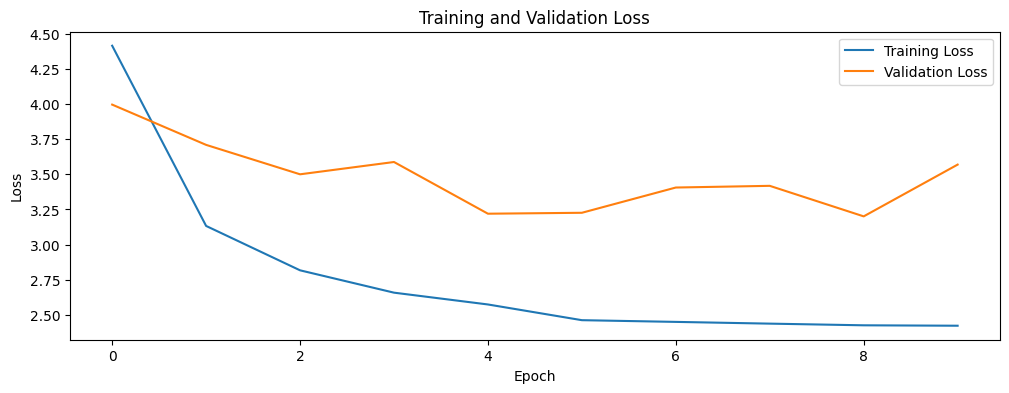

In [61]:
plot_acc(history)
plot_loss(history)

#### 8) Testing V1

In [62]:
# Testing the model on a single image
test_pic = "/kaggle/input/datasets/rahmarizk/flower-dataset-reduced/resized_flower_dataset/valid/bee_balm/image_03065.jpg"

# Load the image and apply the same transformations as during training
image = Image.open(test_pic).convert("RGB")

# Test it without augmentation transforms (No transforms)!!!

test = val_transforms(image).unsqueeze(0)  # Add batch dimension
test = test.to(device)
flower_model.eval()
with torch.no_grad():
    output = flower_model(test)
    _, predicted_class = torch.max(output, 1)
# Load class mapping
with open("class_mapping.json", "r") as f:
    class_mapping = json.load(f)
# Get the predicted class name
predicted_class_name = None
for class_name, idx in class_mapping.items():
    if idx == predicted_class.item():
        predicted_class_name = class_name
        break
print(f"Predicted class: {predicted_class_name} (Index: {predicted_class.item()})")

Predicted class: bee_balm (Index: 28)


#### 9) Fine Tuning Stage 

In [63]:
flower_model.load_state_dict(
    torch.load("/kaggle/working/flower_model.pth")
)

<All keys matched successfully>

In [64]:
for param in flower_model.features.parameters():
    param.requires_grad = False

In [ ]:
# Unfreeze only last blocks
for param in flower_model.features[-4:].parameters():
    param.requires_grad = True

In [ ]:
flower_model = flower_model.to(device)

In [ ]:
# Different learning rates for classifier and last blocks
# Small LR --> for pretrained layers 
# Larger LR --> for new classifier layers
optimizer = torch.optim.Adam([
    {"params": flower_model.classifier.parameters(), "lr": 1e-4},
    {"params": flower_model.features[-4:].parameters(), "lr": 3e-5},
])

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

In [44]:
train_loader = DataLoader(
    train_dataset,
    # batch_size=64,
    batch_size = 32, # for stage 3 only
    shuffle=True,
    # num_workers=0,
    num_workers = 2, # for stage 3 only
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    # batch_size=64,
    batch_size = 32, # for stage 3 only
    shuffle=False,
    # num_workers=0,
     num_workers = 2, # for stage 3 only
    pin_memory=True
)

In [ ]:
# Stage 1 Output: Epoch [10/10] 
# Train Loss: 2.4222, Train Acc: 0.6576 
# Val Loss: 3.5694, Val Acc: 0.5138

In [ ]:
history2 = flower_training(num_epochs=10, model=flower_model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler)

# Saving the trained model  
torch.save(flower_model.state_dict(), "/kaggle/working/flower_model2.pth")

Validation: 100%|██████████| 191/191 [01:35<00:00,  2.00it/s, acc=0.603, loss=1.71]


Epoch [1/10] | Train Loss: 2.2478, Train Acc: 0.6995 | Val Loss: 2.8120, Val Acc: 0.6029


Validation: 100%|██████████| 191/191 [01:33<00:00,  2.04it/s, acc=0.627, loss=1.68]


Epoch [2/10] | Train Loss: 2.0803, Train Acc: 0.7490 | Val Loss: 2.9325, Val Acc: 0.6272


Validation: 100%|██████████| 191/191 [01:35<00:00,  2.01it/s, acc=0.642, loss=1.55]


...

Epoch [8/10] | Train Loss: 1.8215, Train Acc: 0.8243 | Val Loss: 2.6867, Val Acc: 0.6667


Validation: 100%|██████████| 191/191 [01:35<00:00,  2.01it/s, acc=0.667, loss=1.53]


Epoch [9/10] | Train Loss: 1.8240, Train Acc: 0.8233 | Val Loss: 3.5170, Val Acc: 0.6667


Validation: 100%|██████████| 191/191 [01:34<00:00,  2.03it/s, acc=0.669, loss=1.5] 

Epoch [10/10] | Train Loss: 1.8221, Train Acc: 0.8244 | Val Loss: 2.9806, Val Acc: 0.6691


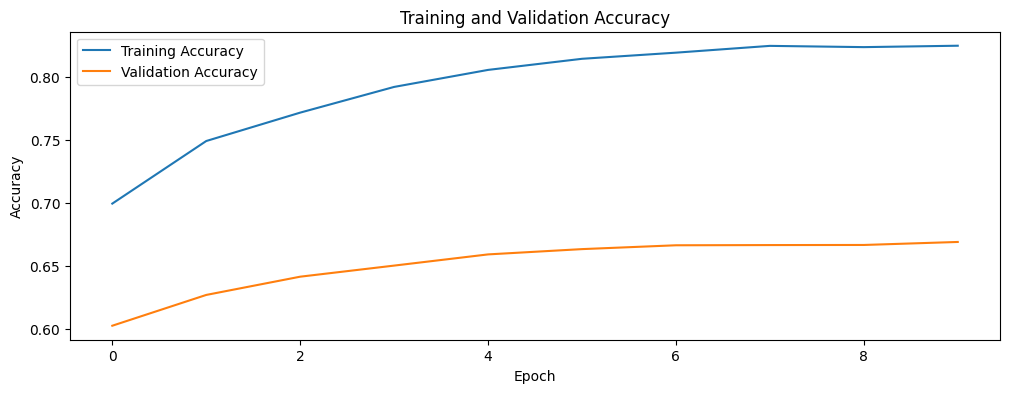

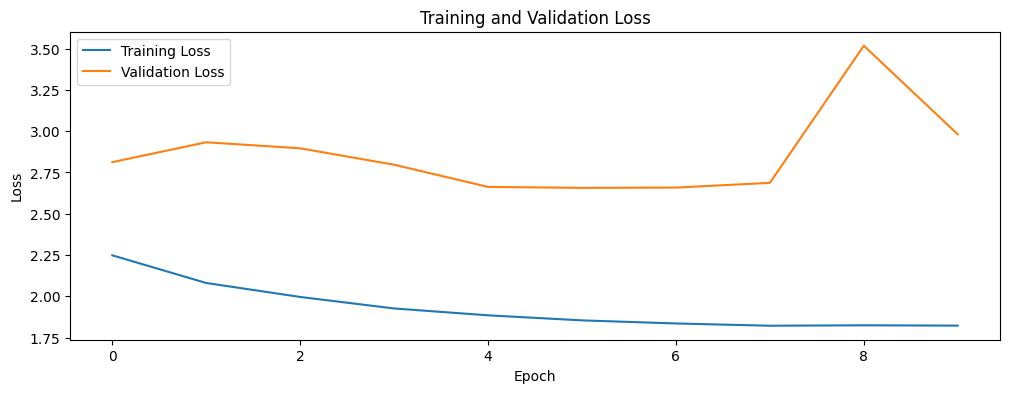

In [ ]:
plot_acc(history2)
plot_loss(history2)

#### 10) More Fine Tuning (Stage 3)

In [ ]:
flower_model.load_state_dict(
    torch.load("/kaggle/working/flower_model2.pth")
)

<All keys matched successfully>

In [34]:
for param in flower_model.features.parameters():
    param.requires_grad = False

In [35]:
for p in flower_model.features[-8:].parameters():
    p.requires_grad = True

In [36]:
flower_model = flower_model.to(device)

In [47]:
optimizer = torch.optim.AdamW([
    {"params": flower_model.classifier.parameters(), "lr": 5e-5},
    {"params": flower_model.features[-8:].parameters(), "lr": 1e-5},
], weight_decay=1e-4)

In [39]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

In [48]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Stage 2 output: Epoch [10/10] 
# Train Loss: 1.8221, Train Acc: 0.8244 
# Val Loss: 2.9806, Val Acc: 0.6691

In [ ]:
history3 = flower_training(num_epochs=5, model=flower_model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler)

# Saving the trained model  
torch.save(flower_model.state_dict(), "/kaggle/working/flower_model3.pth")

Validation: 100%|██████████| 381/381 [00:57<00:00,  6.62it/s, acc=0.678, loss=1.48]


Epoch [1/5] | Train Loss: 1.8538, Train Acc: 0.8119 | Val Loss: 2.8167, Val Acc: 0.6781


Validation: 100%|██████████| 381/381 [00:44<00:00,  8.64it/s, acc=0.686, loss=1.46]


Epoch [2/5] | Train Loss: 1.8157, Train Acc: 0.8246 | Val Loss: 2.5041, Val Acc: 0.6862


Validation: 100%|██████████| 381/381 [00:56<00:00,  6.76it/s, acc=0.691, loss=1.43]


Epoch [3/5] | Train Loss: 1.7820, Train Acc: 0.8358 | Val Loss: 2.8373, Val Acc: 0.6912


Validation: 100%|██████████| 381/381 [00:46<00:00,  8.13it/s, acc=0.697, loss=1.42]


Epoch [4/5] | Train Loss: 1.7561, Train Acc: 0.8437 | Val Loss: 2.3665, Val Acc: 0.6973


Epoch 5 Training:  95%|█████████▍| 989/1042 [10:27<00:33,  1.58it/s, acc=0.849, loss=1.69]

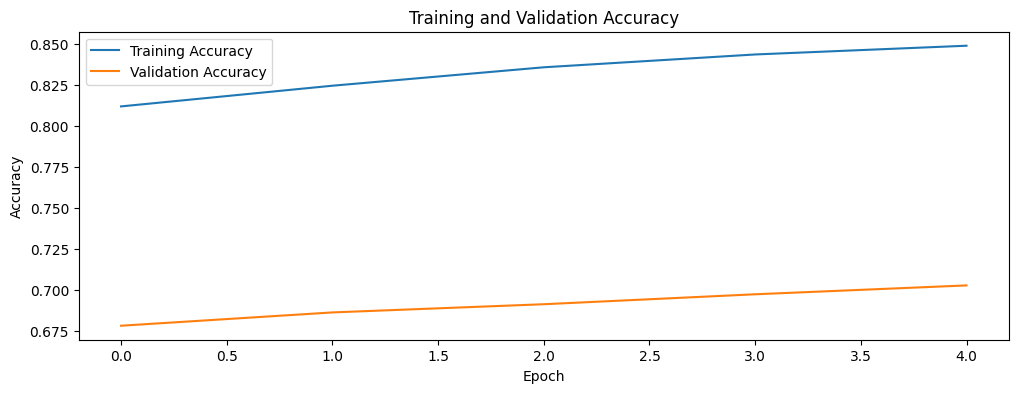

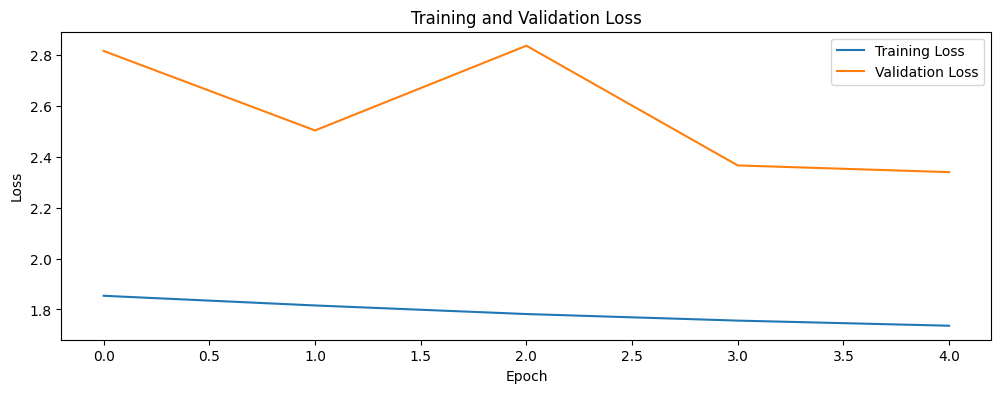

In [50]:
plot_acc(history3)
plot_loss(history3)

#### 11) Testing V2

In [51]:
flower_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = flower_model(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", correct / total)

Validation Accuracy: 0.7026738845144357


In [ ]:
# Final Validation Accuracy: 0.7026738845144357

#### 12) Model serialization for deployment

In [54]:
# Converting to TorchScript
# This creates a portable inference model.
flower_model.eval()

example_input = torch.randn(1, 3, 224, 224).to(device)

scripted_model = torch.jit.trace(
    flower_model,
    example_input
)

torch.jit.save(
    scripted_model,
    "/kaggle/working/flower_model_scripted.pt"
)